In [1]:
import pandas as pd
import plotly.express as px


# Dataset: Gapminder — GDP, Life Expectancy, Population by Country
# Source: Gapminder Foundation (gapminder.org)

df = px.data.gapminder()
print(f"Loaded: {len(df)} rows")
print(df.head())

Loaded: 1704 rows
       country continent  year  lifeExp       pop   gdpPercap iso_alpha  \
0  Afghanistan      Asia  1952   28.801   8425333  779.445314       AFG   
1  Afghanistan      Asia  1957   30.332   9240934  820.853030       AFG   
2  Afghanistan      Asia  1962   31.997  10267083  853.100710       AFG   
3  Afghanistan      Asia  1967   34.020  11537966  836.197138       AFG   
4  Afghanistan      Asia  1972   36.088  13079460  739.981106       AFG   

   iso_num  
0        4  
1        4  
2        4  
3        4  
4        4  


In [2]:
print(df.info())
print("Years:", sorted(df['year'].unique()))
print("Continents:", df['continent'].unique())
print(df.describe().round(1))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1704 entries, 0 to 1703
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   country    1704 non-null   object 
 1   continent  1704 non-null   object 
 2   year       1704 non-null   int64  
 3   lifeExp    1704 non-null   float64
 4   pop        1704 non-null   int64  
 5   gdpPercap  1704 non-null   float64
 6   iso_alpha  1704 non-null   object 
 7   iso_num    1704 non-null   int64  
dtypes: float64(2), int64(3), object(3)
memory usage: 106.6+ KB
None
Years: [np.int64(1952), np.int64(1957), np.int64(1962), np.int64(1967), np.int64(1972), np.int64(1977), np.int64(1982), np.int64(1987), np.int64(1992), np.int64(1997), np.int64(2002), np.int64(2007)]
Continents: ['Asia' 'Europe' 'Africa' 'Americas' 'Oceania']
         year  lifeExp           pop  gdpPercap  iso_num
count  1704.0   1704.0  1.704000e+03     1704.0   1704.0
mean   1979.5     59.5  2.960121e+07     7215.3    

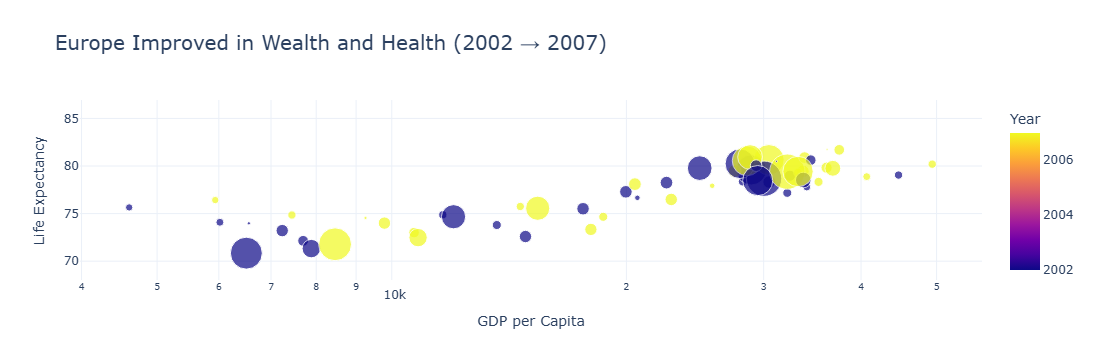

In [3]:
# Task 1
continent_choice = "Europe"

df_scatter = df.loc[
    (df['continent'] == continent_choice) &
    (df['year'].isin([2002, 2007]))
]

# Scatter plot
fig1 = px.scatter(
    df_scatter,
    x="gdpPercap",
    y="lifeExp",
    color="year",
    hover_name="country",
    size="pop",
    size_max=25,
    color_discrete_sequence=["#1f77b4", "#ff7f0e"],
    title=f"Europe Improved in Wealth and Health (2002 → 2007)",
    labels={
        "gdpPercap": "GDP per Capita",
        "lifeExp": "Life Expectancy",
        "year": "Year"
    }
)

# Log scale for GDP
fig1.update_xaxes(type="log")

# Improve layout
fig1.update_layout(
    template="plotly_white",
    title_font_size=20
)

# Annotation to explain trend
fig1.add_annotation(
    x=30000,
    y=82,
    text="Most countries moved toward<br>higher GDP and longer lives",
    showarrow=True,
    arrowhead=2
)

fig1.show()

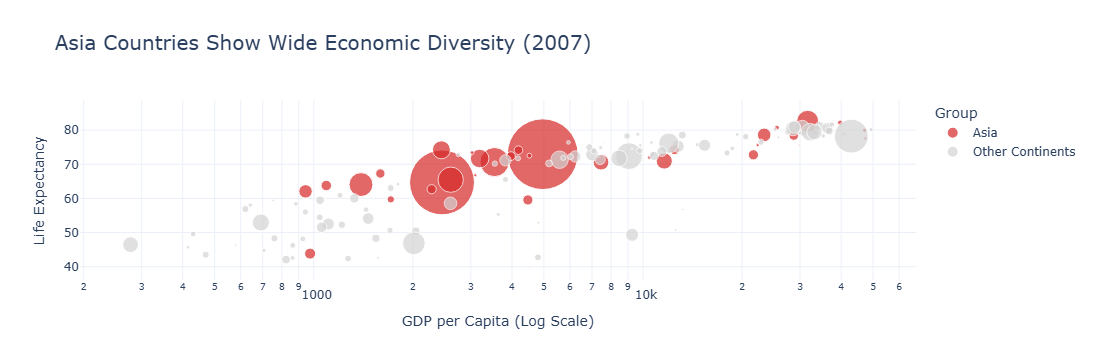

In [4]:
# Task 2
# Full dataset for 2007
df_2007 = df[df['year'] == 2007].copy()

# Choose one continent to highlight
highlight_continent = "Asia"

# Create colour column
df_2007["highlight"] = df_2007["continent"].apply(
    lambda x: highlight_continent if x == highlight_continent else "Other Continents"
)

# Bubble chart
fig2 = px.scatter(
    df_2007,
    x="gdpPercap",
    y="lifeExp",
    size="pop",
    color="highlight",
    hover_name="country",
    size_max=50,
    log_x=True,
    title=f"{highlight_continent} Countries Show Wide Economic Diversity (2007)",
    labels={
        "gdpPercap": "GDP per Capita (Log Scale)",
        "lifeExp": "Life Expectancy",
        "highlight": "Group"
    },
    color_discrete_map={
        highlight_continent: "#d62728",
        "Other Continents": "lightgrey"
    }
)

# Clean style
fig2.update_layout(
    template="plotly_white",
    title_font_size=20
)

# Annotation/story insight
fig2.add_annotation(
    x=4000,
    y=72,
    text="Asian countries range from<br>developing to highly wealthy economies",
    showarrow=True,
    arrowhead=2
)

fig2.show()